In [1]:
HOME_DIR='/home/mkairov'
RUN_DIR = f"{HOME_DIR}/test_time_gd/runs"

%load_ext autoreload
%autoreload 2

import os
os.chdir(f'{HOME_DIR}/test_time_gd/')

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
from typing import Optional
from dataclasses import dataclass, field
from grad_rmt import GradRMT, GradRMTConfig

@dataclass
class ExperimentArgs:
    exp_path: str = field()
    per_device_batch_size: int = field()
    data_path: str = field(
        default='./data/N2-K4V4-S4(32-64)_1M',
    )
    tokenizer_path: str = field(
        default='./tokenizers/kv_alphabet_62/',
    )
    gradient_accumulation_steps: Optional[int] = field(default=1)
    total_batch_size: Optional[int] = field(default=None)
    metric_for_best_model: Optional[str] = field(default='token_accuracy')
    warmup_steps: Optional[int] = field(default=1000)
    max_steps: Optional[int] = field(default=50000)
    logging_steps: Optional[int] = field(default=100)
    eval_steps: Optional[int] = field(default=100)
    weight_decay: Optional[float] = field(default=0.0)
    learning_rate: Optional[float] = field(default=1e-04)
    lr_scheduler_type: Optional[str] = field(default='constant_with_warmup')
    early_stopping_patience: Optional[int] = field(default=50)
    seed: Optional[int] = field(default=142)
    base_model: Optional[str] = field(default=None)
    pretrained_model: Optional[str] = field(default=None)
    init_checkpoint: Optional[str] = field(default=None)
    n_layer: Optional[int] = field(default=4)
    n_head: Optional[int] = field(default=4)
    n_embd: Optional[int] = field(default=128)
    # GradRMT parameters
    n_mem_tokens: Optional[int] = field(default=8)
    K: Optional[int] = field(default=3)
    last_K_second_order: Optional[int] = field(default=None)
    inner_lr: Optional[float] = field(default=0.01)
    learn_lr: Optional[bool] = field(default=False)
    inner_optim: Optional[str] = field(default="sgd")
    grad_mode: Optional[str] = field(default="none")
    momentum_mode: Optional[str] = field(default="none")
    n_ctrl_tokens: Optional[int] = field(default=0)
    inner_clip_value: Optional[float] = field(default=None)
    inner_clip_norm: Optional[float] = field(default=None)
    use_mem_proj: Optional[bool] = field(default=False)
    mem_proj_mode: Optional[str] = field(default="none")
    use_write_head: Optional[bool] = field(default=False)
    use_mem_attn: Optional[bool] = field(default=False)
    use_retrieval: Optional[bool] = field(default=False)
    segment_size: int = field(default=None)
    use_gradient_checkpointing: Optional[bool] = field(default=False)

In [3]:
from transformers import AutoConfig, AutoTokenizer
from safetensors.torch import load_file
import json
from pathlib import Path

def prepare_model(run_path):
    # get best saved checkpoint
    best_score = -1
    best_cpt = None
    for cpt_path in Path(run_path).glob('**/checkpoint-*'):
        cpt_state = json.load(open(f'{cpt_path}/trainer_state.json'))
        cur_score = cpt_state['log_history'][-1]['eval_token_accuracy']
        if cur_score > best_score:
            best_score = cur_score
            best_cpt = str(cpt_path)

    # load args for original experiment
    CPT_PATH = f"{best_cpt}/model.safetensors"
    cli_config = json.load(open(f'{run_path}/config.json'))['cli_args']
    cli_config['init_checkpoint'] = CPT_PATH
    args = ExperimentArgs(**cli_config)

    # load/create backbone
    if args.pretrained_model is None:
        # create tokenizer
        tokenizer = AutoTokenizer.from_pretrained(args.tokenizer_path)
        # create base model config
        if args.base_model == 'gpt2':
            config = AutoConfig.from_pretrained('gpt2')
            config.n_layer = args.n_layer
            config.n_head = args.n_head
            config.n_embd = args.n_embd
        elif args.base_model == 'pythia':
            config = AutoConfig.from_pretrained('EleutherAI/pythia-160m')
            config.num_hidden_layers = args.n_layer
            config.num_attention_heads = args.n_head
            config.hidden_size = args.n_embd
            config.intermediate_size = config.hidden_size * 4
        elif args.base_model == 'llama':
            # config = AutoConfig.from_pretrained('meta-llama/Llama-3.2-1B')
            config = AutoConfig.from_pretrained('unsloth/Llama-3.2-1B')
            config.num_hidden_layers = args.n_layer
            config.num_attention_heads = args.n_head
            config.num_key_value_heads = args.n_head
            config.hidden_size = args.n_embd
            config.head_dim = config.hidden_size // config.num_attention_heads
            config.intermediate_size = config.hidden_size * 4
        else:
            raise ValueError(f'Unsupported base model: {args.base_model}')
        
        config.torch_dtype = "float32"  # weights in float32, at training precision is controlled by accelerate
        config.vocab_size = tokenizer.vocab_size
        config.pad_token_id = tokenizer.pad_token_id
        config.bos_token_id = tokenizer.bos_token_id
        config.eos_token_id = tokenizer.eos_token_id
        config.use_cache = False

    else:
        config = None
        tokenizer = AutoTokenizer.from_pretrained(args.pretrained_model)
        if tokenizer.pad_token_id is None:
            tokenizer.pad_token_id = tokenizer.eos_token_id

    # initialize GradRMT model
    gradrmt_config = GradRMTConfig(pretrained_model=args.pretrained_model, base_config=config,
                                        n_mem_tokens=args.n_mem_tokens, K=args.K,
                                        last_K_second_order=args.last_K_second_order,
                                        lr=args.inner_lr, learn_lr=args.learn_lr, inner_optim=args.inner_optim,
                                        grad_mode=args.grad_mode, momentum_mode=args.momentum_mode,
                                        n_ctrl_tokens=args.n_ctrl_tokens,
                                        inner_clip_value=args.inner_clip_value, inner_clip_norm=args.inner_clip_norm,
                                        use_mem_proj=args.use_mem_proj, mem_proj_mode=args.mem_proj_mode,
                                        use_write_head=args.use_write_head, segment_size=args.segment_size,
                                        use_mem_attn=args.use_mem_attn, use_retrieval=args.use_retrieval,
                                        use_gradient_checkpointing=args.use_gradient_checkpointing)

    # Create gradmemgpt model
    model = GradRMT(gradrmt_config)

    # load existing checkpoint
    if args.init_checkpoint is not None:
        missing_k, unexpected_k = model.load_state_dict(load_file(args.init_checkpoint), strict=False)
        if len(missing_k) != 0:
            print(f'{missing_k} were not loaded from checkpoint! These parameters were randomly initialized.')
        if len(unexpected_k) != 0:
            print(f'{unexpected_k} were found in checkpoint, but model is not expecting them!')
        model.model.tie_weights()
    
    return model, tokenizer, args


In [4]:
# set this for all runs
PAIR_LEN = 7
PAIRS_PER_SEGMENT = 8

# depends on the run
N_PAIRS = 32
N_SEGMENTS = 4
K = 1
ilr = 1.0

runs_path = "/home/mkairov/test_time_gd/runs/N32-K2V2-V62_1M/gradrmt_llama_L4H4D128_mem8_s4_K3_ilr0.04_mem_proj_whead_sgd_grad_second_m_none_bs_64_lr_1e-04"
# runs_path = f"{RUN_DIR}/N{N_PAIRS}-K2V2-V62_1M/gradrmt_llama_L4H4D128_mem8_s{N_SEGMENTS}_K{K}_ilr{ilr}_mem_proj_whead_sgd_grad_second_m_none_bs_64_lr_1e-04_from_N32_s4"

model_list = []
for run_path in Path(runs_path).glob('**/run_*'):
    model, tokenizer, args = prepare_model(run_path)
    model_list.append(model)

N_MODELS = len(model_list)

['model.lm_head.weight'] were not loaded from checkpoint! These parameters were randomly initialized.
['model.lm_head.weight'] were not loaded from checkpoint! These parameters were randomly initialized.


In [5]:
import torch

def get_query_pos(seqs, keys):
    B, L = seqs.shape
    K = keys.shape[1]
    T = L - K + 1  # number of valid start positions in each row

    windows = seqs.unfold(dimension=1, size=K, step=1)
    matches = (windows == keys.unsqueeze(1))
    mask = matches.all(dim=2)
    cum = mask.cumsum(dim=1)
    first_hit_mask = (cum == 1) & mask    # [B, T] bool, exactly one True per row if any match exists
    arange_T = torch.arange(T, device=seqs.device)  # [T]
    idxs = (first_hit_mask * arange_T).max(dim=1).values  # [B]
    return idxs 


def collate_fn(batch, tokenizer):
    context = [item['context'].replace('|', '') for item in batch]
    query = [item['query'] + item['target'] for item in batch]

    context_input_ids = tokenizer(context, return_tensors="pt", add_special_tokens=True,
                                  padding=True, pad_to_multiple_of=8).input_ids
    query_encoded = tokenizer(query, return_tensors="pt", add_special_tokens=True,
                              padding=True, pad_to_multiple_of=8, return_offsets_mapping=True)
    query_input_ids = query_encoded['input_ids']
    offsets_mapping = query_encoded['offset_mapping']

    # add labels_mask
    # input_seq: 0, target_seq: 1, seq = input_seq + target_seq
    labels_mask = torch.zeros_like(query_input_ids)
    for i, item in enumerate(batch):
        query_seq_len = len(item['query'])
        target_seq_len = len(item['target'])
        target_st, target_end = query_seq_len, query_seq_len + target_seq_len
        # find target tokens
        # since target is closer to the end (context, query, target), search from the end
        in_target = False
        for j in range(len(offsets_mapping[i]) - 1, -1, -1):
            st, end = offsets_mapping[i][j]
            # if (target_st, target_end) intersects with (st, end), it is a target token
            if st < target_end and end > target_st:
                labels_mask[i, j] = 1
                in_target = True
            elif in_target:
                break

    labels = query_input_ids * labels_mask + (1 - labels_mask) * -100

    real_query_len = (query_input_ids != 0).sum(dim=1).max()
    answer_positions = get_query_pos(context_input_ids, query_input_ids[:, 1:real_query_len - 1])
    return {
        'input_ids': {
            'context_input_ids': context_input_ids,
            'query_input_ids': query_input_ids,
        },
        'labels': labels,
        'answer_positions': answer_positions,
    }

In [6]:
import datasets
from torch.utils.data import DataLoader

dataset = datasets.load_dataset(f'yurakuratov/{args.data_path}')

def data_collator(batch):
    return collate_fn(batch, tokenizer)

ignore_token_ids = [tokenizer.convert_tokens_to_ids(t) for t in ['!', '|']]

valid_dataloader = DataLoader(
    dataset['valid'], batch_size=64, collate_fn=data_collator,
)

In [7]:
import numpy as np

res = []
for i in range(N_MODELS):
    model_list[i].eval()
    model_list[i].to('cuda')
    res.append({
        'preds': [],
        'labels': [],
        'pair_pos': [],
    })

with torch.no_grad():
    for batch in valid_dataloader:
        # Move batch to device
        answer_positions = batch.pop('answer_positions').cpu().numpy()
        batch = {k: v.to('cuda') if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

        for k, v in batch['input_ids'].items():
            batch['input_ids'][k] = v.to('cuda')
        batch['labels'].to('cuda')
        
        for i in range(N_MODELS):
            outputs = model_list[i](**batch)
            logits = outputs['predictions']

            preds = torch.argmax(logits, dim=-1) if logits.dim() > 1 and logits.shape[-1] > 1 else logits
            labels = batch.get('labels')

            res[i]['pair_pos'].append(answer_positions)
            res[i]['preds'].append(preds.cpu().numpy())
            res[i]['labels'].append(labels.cpu().numpy())


preds = np.stack([np.concatenate(m['preds'], axis=0) for m in res], axis=0)
labels = np.stack([np.concatenate(m['labels'], axis=0) for m in res], axis=0)
pair_pos = np.stack([np.concatenate(m['pair_pos'], axis=0) for m in res], axis=0)

In [8]:
import numpy as np

preds_ = preds[..., :-1]
labels_ = labels[..., 1:]

# Create a mask for tokens that are not padding (-100) and ignored tokens (like ! and |)
mask = (labels_ != -100)
for t_id in ignore_token_ids:
    mask &= (labels_ != t_id)

# Calculate token-level accuracy only on content tokens
masked_predictions = preds_[mask].reshape(N_MODELS, -1)  # axis tricks (mask flattens arrays)
masked_labels = labels_[mask].reshape(N_MODELS, -1)

token_accuracy = (masked_predictions == masked_labels).mean(axis=1)
exact_match = np.mean([
    np.all(pred[mask[:, i]].reshape(N_MODELS, -1) == lab[mask[:, i]].reshape(N_MODELS, -1), axis=1)
    for i, (pred, lab) in enumerate(zip(preds_.transpose(1, 0, 2), labels_.transpose(1, 0, 2)))  # transpose to zip along 1st axis
    if np.any(mask[:, i])  # Skip samples that are all masked
], axis=0)  # [n_samples, n_models] -> [n_models]

print(f"Exact Match: {100 * float(exact_match.mean()):.4f} +- {100 * float(exact_match.std()):.4f}")
print(f"Token Accuracy: {100 * float(token_accuracy.mean()):.4f} +- {100 * float(token_accuracy.std()):.4f}")

Exact Match: 95.9000 +- 0.9800
Token Accuracy: 97.9100 +- 0.4900


In [ ]:
seg_err_stat = []
inner_err_stat = []

for i in range(N_MODELS):
    mismatch_flags = np.array([
        np.any(pred[mask[i, j]] != lab[mask[i, j]])
        for j, (pred, lab) in enumerate(zip(preds_[i], labels_[i]))
        if np.any(mask[i, j])  # Skip samples that are all masked
    ])
    error_pos = pair_pos[i][mismatch_flags]
    segment_error_pos = np.bincount(error_pos // (PAIR_LEN * (N_PAIRS // N_SEGMENTS)), minlength=N_SEGMENTS)
    within_segment_error_pos = np.bincount(np.remainder(error_pos // PAIR_LEN, (N_PAIRS // N_SEGMENTS)), minlength=(N_PAIRS // N_SEGMENTS))

    segment_answer_pos = np.bincount(pair_pos[i] // (PAIR_LEN * (N_PAIRS // N_SEGMENTS)), minlength=N_SEGMENTS)
    within_segment_answer_pos = np.bincount(np.remainder(pair_pos[i] // PAIR_LEN, (N_PAIRS // N_SEGMENTS)), minlength=(N_PAIRS // N_SEGMENTS))

    seg_err_stat.append(segment_error_pos / segment_answer_pos)
    inner_err_stat.append(within_segment_error_pos / within_segment_answer_pos)

seg_err_stat = np.stack(seg_err_stat)
inner_err_stat = np.stack(inner_err_stat)

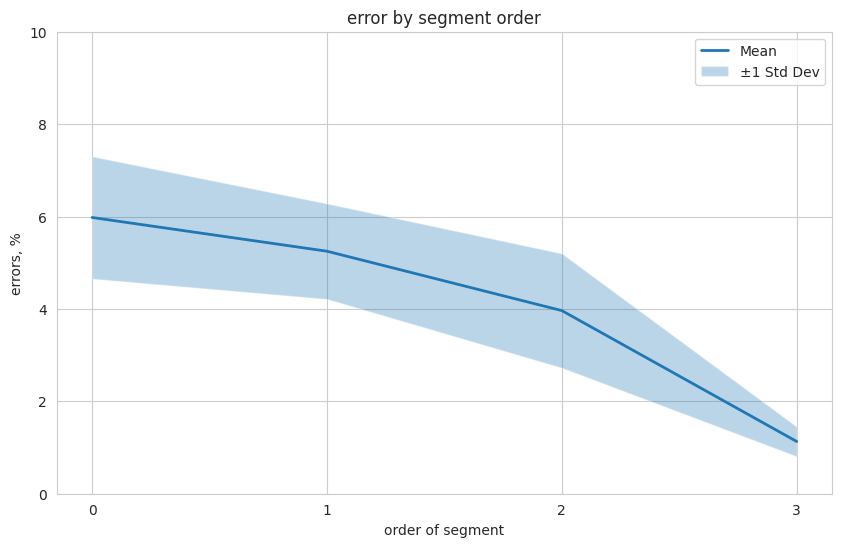

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

data = seg_err_stat * 100
mean = data.mean(axis=0)
std = data.std(axis=0)

x = np.arange(data.shape[1])
plt.plot(x, mean, label='Mean', linewidth=2)
plt.fill_between(x, mean - std, mean + std, alpha=0.3, label='±1 Std Dev')
plt.xticks(x)

plt.ylim(0, 10)
plt.xlabel('order of segment')
plt.ylabel('errors, %')
plt.title('error by segment order')
plt.legend()
plt.show()